# PK Figure -> CSV (automatic)

Companion to `pk_figure_to_csv.ipynb`. Same goal: extract observed data points from a pharmacokinetic time-concentration plot and save them to a CSV. The difference is that no clicks are required: the marker positions are found automatically.

**Pipeline**

1. **Plot area.** Auto-detect the plot bounding box from the axis spines. Calibrate axes by mapping the box to user-supplied data ranges (linear or log).
2. **Saturated mask.** Keep only colored pixels (drops white background, near-black axis lines, anti-aliased gray text). An optional `exclude_regions` masks out the legend.
3. **Candidate markers.** Light morphology -> connected components -> filter by area. *Conservatively split* any blob much larger than a typical marker into multiple candidate centroids (each peak of the distance transform). This handles the case where two markers from different trajectories overlap at the same (x, y).
4. **Line-aware grouping.** Build a graph in which two candidate markers are connected if a *thin saturated path* of similar color runs between them (i.e. the interpolated line drawn in the figure). Connected components of this graph are trajectories -- this lets the algorithm group markers that share a color *and* a line, even when K-means on color alone would mix them.
5. **Match to user count.** Ask the user how many trajectories are in the figure. If the graph produced more groups, merge the closest in mean color until we hit that count. If it produced fewer (the lines bridged across trajectories in a dense region), report what was found and recommend the click notebook.
6. **Export.** Convert centroids to data coords and write to CSV; verify with an overlay on the original image and a re-plot.

**Where this works.** Figures whose trajectories use distinct, saturated colors and don't crowd into a single dense lump near one corner. The bundled paclitaxel example is hard: seven trajectories share desaturated red/pink and blue/purple hues and crowd tightly at early time points, so the line-connectivity step bridges several of them together. Treat the auto output as a draft to inspect; for high-fidelity extraction or for grayscale-only figures (the cisplatin example), use the click notebook.

**Dependencies.** `numpy`, `scipy`, `scikit-learn`, `matplotlib`, `pandas`, `Pillow`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi

## The auto-extractor

In [2]:
class PKFigureAutoExtractor:
    """Automatic point extractor with line-aware grouping and overlap split."""

    def __init__(self, image_path, x_range, y_range, x_log=False, y_log=False):
        self.image_path = Path(image_path)
        self.img = np.array(Image.open(self.image_path).convert("RGB"))
        self.x_range = tuple(x_range)
        self.y_range = tuple(y_range)
        self.x_log = x_log
        self.y_log = y_log
        for is_log, rng, name in [(x_log, self.x_range, "x"), (y_log, self.y_range, "y")]:
            if is_log and (rng[0] <= 0 or rng[1] <= 0):
                raise ValueError(f"{name}-axis is log: range bounds must be > 0.")
        self.plot_area = None
        self.x_refs = None
        self.y_refs = None
        self.trajectories = {}
        self._cluster_pixel_centroids = {}
        self._valid_mask = None
        self._crop_pad = 2
        self._blobs = []
        self._edges = []

    # ---------- step 1: plot area ----------
    def detect_plot_area(self, dark_thresh=80, min_line_frac=0.3):
        gray = self.img.mean(axis=2)
        dark = gray < dark_thresh
        h, w = dark.shape
        min_h_len = int(min_line_frac * w)
        min_v_len = int(min_line_frac * h)

        def longest_run(line):
            d = np.diff(np.concatenate(([0], line.astype(int), [0])))
            starts = np.where(d == 1)[0]
            ends = np.where(d == -1)[0]
            if len(starts) == 0:
                return 0, 0, 0
            lens = ends - starts
            i = int(lens.argmax())
            return int(lens[i]), int(starts[i]), int(ends[i])

        h_rows = [r for r in range(h) if longest_run(dark[r])[0] >= min_h_len]
        v_cols = [c for c in range(w) if longest_run(dark[:, c])[0] >= min_v_len]
        if not h_rows or not v_cols:
            raise RuntimeError(
                "Could not detect plot axes. Set plot_area manually via set_plot_area()."
            )
        bottom = max(h_rows)
        left = min(v_cols)
        _, top, _ = longest_run(dark[:, left])
        _, _, right = longest_run(dark[bottom, :])
        self.plot_area = (int(left), int(top), int(right), int(bottom))
        self._calibrate_from_plot_area()
        return self.plot_area

    def set_plot_area(self, left, top, right, bottom):
        self.plot_area = (int(left), int(top), int(right), int(bottom))
        self._calibrate_from_plot_area()

    def _calibrate_from_plot_area(self):
        L, T, R, B = self.plot_area
        self.x_refs = [(L, self.x_range[0]), (R, self.x_range[1])]
        self.y_refs = [(B, self.y_range[0]), (T, self.y_range[1])]

    # ---------- coordinate conversion ----------
    def pixel_to_data(self, px, py):
        (xpa, xva), (xpb, xvb) = self.x_refs
        if self.x_log:
            la, lb = np.log10(xva), np.log10(xvb)
            x = 10 ** (la + (px - xpa) * (lb - la) / (xpb - xpa))
        else:
            x = xva + (px - xpa) * (xvb - xva) / (xpb - xpa)
        (ypa, yva), (ypb, yvb) = self.y_refs
        if self.y_log:
            la, lb = np.log10(yva), np.log10(yvb)
            y = 10 ** (la + (py - ypa) * (lb - la) / (ypb - ypa))
        else:
            y = yva + (py - ypa) * (yvb - yva) / (ypb - ypa)
        return float(x), float(y)

    @staticmethod
    def _disk(radius):
        r = int(radius)
        y, x = np.ogrid[-r:r + 1, -r:r + 1]
        return x * x + y * y <= r * r

    @staticmethod
    def _local_maxima(arr, min_dist, threshold):
        fp = 2 * int(min_dist) + 1
        return np.argwhere((ndi.maximum_filter(arr, size=fp) == arr) & (arr >= threshold))

    @staticmethod
    def _line_color_around(py, px, valid, crop, exclude_radius=4, sample_radius=12):
        h, w = valid.shape
        pix = []
        for dx in range(exclude_radius, sample_radius + 1):
            for sign in (-1, 1):
                x = int(round(px) + sign * dx)
                if not (0 <= x < w):
                    continue
                for dy in range(-3, 4):
                    y = int(round(py) + dy)
                    if 0 <= y < h and valid[y, x]:
                        pix.append(crop[y, x])
        if not pix:
            return None
        return np.array(pix).mean(axis=0)

    # ---------- step 2: detection ----------
    def detect_markers(
        self,
        n_trajectories,
        min_saturation=20,
        value_range=(40, 240),
        exclude_regions=None,
        crop_pad=2,
        close_radius=1,
        open_radius=1,
        min_blob_area=8,
        max_blob_area=1500,
        overlap_size_factor=3.0,
        overlap_peak_min_dist=6,
        overlap_peak_threshold=2.5,
        line_max_distance=70,
        line_near_threshold=0.55,
        line_color_threshold=0.30,
        line_color_dist=70,
    ):
        """End-to-end detection. See class docstring for the pipeline."""
        if self.plot_area is None:
            raise RuntimeError("Call detect_plot_area() or set_plot_area() first.")
        self._crop_pad = crop_pad
        L, T, R, B = self.plot_area
        crop = self.img[T + crop_pad: B - crop_pad, L + crop_pad: R - crop_pad]
        ch, cw = crop.shape[:2]

        # ---- saturated mask ----
        rgb_min = crop.min(axis=2)
        rgb_max = crop.max(axis=2)
        sat = rgb_max.astype(int) - rgb_min.astype(int)
        valid = (
            (sat >= min_saturation)
            & (rgb_max >= value_range[0])
            & (rgb_max <= value_range[1])
        )
        if exclude_regions:
            for (rL, rT, rR, rB) in exclude_regions:
                x0 = max(0, int(rL) - L - crop_pad)
                y0 = max(0, int(rT) - T - crop_pad)
                x1 = min(cw, int(rR) - L - crop_pad)
                y1 = min(ch, int(rB) - T - crop_pad)
                if x1 > x0 and y1 > y0:
                    valid[y0:y1, x0:x1] = False
        self._valid_mask = valid.copy()

        # ---- candidate marker blobs ----
        m = valid.copy()
        if close_radius > 0:
            m = ndi.binary_closing(m, structure=self._disk(close_radius))
        if open_radius > 0:
            m = ndi.binary_opening(m, structure=self._disk(open_radius))
        labeled, n_blobs = ndi.label(m)
        if n_blobs == 0:
            raise RuntimeError("No saturated blobs found. Lower min_saturation.")
        sizes = ndi.sum(m, labeled, index=range(1, n_blobs + 1)).astype(int)
        in_range = [s for s in sizes if min_blob_area <= s <= max_blob_area]
        if not in_range:
            raise RuntimeError("No blobs in the configured size range.")
        typical = float(np.median(in_range))

        blobs = []
        for i in range(n_blobs):
            s = int(sizes[i])
            if s < min_blob_area or s > max_blob_area:
                continue
            bm = labeled == (i + 1)
            # Conservative overlap split: only when blob is much bigger than typical
            if s > overlap_size_factor * typical:
                dist = ndi.distance_transform_edt(bm)
                peaks = self._local_maxima(
                    dist,
                    min_dist=overlap_peak_min_dist,
                    threshold=overlap_peak_threshold,
                )
                if len(peaks) > 1:
                    for py, px in peaks:
                        lc = self._line_color_around(py, px, valid, crop)
                        color = lc if lc is not None else crop[bm].mean(axis=0)
                        blobs.append({
                            "cy": float(py), "cx": float(px),
                            "color": color, "size": s, "split": True,
                        })
                    continue
            cy, cx = ndi.center_of_mass(bm)
            blobs.append({
                "cy": float(cy), "cx": float(cx),
                "color": crop[bm].mean(axis=0), "size": s, "split": False,
            })
        if not blobs:
            raise RuntimeError("No candidate markers after overlap split.")
        self._blobs = blobs

        # ---- line-connectivity graph ----
        near = ndi.binary_dilation(valid, iterations=1)
        edges = []
        N = len(blobs)
        parent = list(range(N))

        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x

        def union(x, y):
            px, py = find(x), find(y)
            if px != py:
                parent[px] = py

        for i in range(N):
            for j in range(i + 1, N):
                b1, b2 = blobs[i], blobs[j]
                dx = b2["cx"] - b1["cx"]
                dy = b2["cy"] - b1["cy"]
                d = (dx * dx + dy * dy) ** 0.5
                if d > line_max_distance:
                    continue
                if np.linalg.norm(b1["color"] - b2["color"]) > 90:
                    continue
                n = max(int(d / 2) + 5, 10)
                xs = np.linspace(b1["cx"], b2["cx"], n)
                ys = np.linspace(b1["cy"], b2["cy"], n)
                near_count = 0
                color_count = 0
                for x, y in zip(xs, ys):
                    ix, iy = int(round(x)), int(round(y))
                    if 0 <= iy < ch and 0 <= ix < cw and near[iy, ix]:
                        near_count += 1
                        c = crop[iy, ix].astype(float)
                        if min(np.linalg.norm(c - b1["color"]),
                                np.linalg.norm(c - b2["color"])) < line_color_dist:
                            color_count += 1
                if (near_count / n >= line_near_threshold and
                        color_count / n >= line_color_threshold):
                    union(i, j)
                    edges.append((i, j))
        self._edges = edges

        # connected components
        groups = {}
        for i in range(N):
            groups.setdefault(find(i), []).append(i)
        group_list = sorted(groups.values(), key=len, reverse=True)

        # ---- merge by color until we hit n_trajectories ----
        def merge_closest(gs):
            means = [np.mean([blobs[i]["color"] for i in g], axis=0) for g in gs]
            best_d, bi, bj = np.inf, -1, -1
            for i in range(len(means)):
                for j in range(i + 1, len(means)):
                    d = np.linalg.norm(means[i] - means[j])
                    if d < best_d:
                        best_d, bi, bj = d, i, j
            if bi < 0:
                return gs
            new = [g for k, g in enumerate(gs) if k not in (bi, bj)]
            new.append(gs[bi] + gs[bj])
            return new

        while len(group_list) > n_trajectories:
            group_list = merge_closest(group_list)
        if len(group_list) < n_trajectories:
            print(
                f"[note] line-connectivity produced only {len(group_list)} groups "
                f"(< requested N={n_trajectories}). The lines bridged across "
                f"trajectories somewhere -- inspect step 4, then either re-run "
                f"with stricter line thresholds, or fall back to the click notebook."
            )

        # ---- build trajectories ----
        self.trajectories = {}
        self._cluster_pixel_centroids = {}
        for k, g in enumerate(group_list):
            cols = np.array([blobs[i]["color"] for i in g])
            mean = cols.mean(axis=0).astype(int)
            name = f"cluster_{k}_rgb({mean[0]},{mean[1]},{mean[2]})"
            pixel_pts, data_pts = [], []
            for bi in g:
                b = blobs[bi]
                px = b["cx"] + L + crop_pad
                py = b["cy"] + T + crop_pad
                pixel_pts.append((px, py))
                data_pts.append(self.pixel_to_data(px, py))
            order = np.argsort([p[0] for p in data_pts])
            self.trajectories[name] = [data_pts[i] for i in order]
            self._cluster_pixel_centroids[name] = [pixel_pts[i] for i in order]

    # ---------- visualization ----------
    def visualize_plot_area(self, ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(self.img)
        if self.plot_area is not None:
            L, T, R, B = self.plot_area
            ax.add_patch(plt.Rectangle((L, T), R - L, B - T, fill=False,
                                        edgecolor="lime", lw=1.6))
        ax.set_title(f"Detected plot area: {self.plot_area}")
        ax.set_xticks([]); ax.set_yticks([])
        return ax

    def visualize_valid_mask(self):
        if self._valid_mask is None:
            raise RuntimeError("detect_markers() not yet called.")
        L, T, R, B = self.plot_area
        full = np.zeros(self.img.shape[:2], dtype=bool)
        full[T + self._crop_pad: B - self._crop_pad,
             L + self._crop_pad: R - self._crop_pad] = self._valid_mask
        fig, axes = plt.subplots(1, 2, figsize=(13, 6))
        axes[0].imshow(self.img)
        overlay = np.zeros((*self.img.shape[:2], 4))
        overlay[..., 0] = 1.0
        overlay[..., 3] = full * 0.55
        axes[0].imshow(overlay)
        axes[0].set_title("Pixels passed to morphology+grouping (red overlay)")
        axes[1].imshow(full, cmap="gray")
        axes[1].set_title(f"{int(full.sum())} valid pixels")
        for a in axes:
            a.set_xticks([]); a.set_yticks([])
        return fig

    def visualize_graph(self, ax=None):
        if not self._blobs:
            raise RuntimeError("detect_markers() not yet called.")
        if ax is None:
            _, ax = plt.subplots(figsize=(11, 8))
        ax.imshow(self.img)
        L, T, R, B = self.plot_area
        pad = self._crop_pad
        for (i, j) in self._edges:
            b1, b2 = self._blobs[i], self._blobs[j]
            ax.plot([b1["cx"] + L + pad, b2["cx"] + L + pad],
                    [b1["cy"] + T + pad, b2["cy"] + T + pad],
                    "-", color="lime", lw=0.6, alpha=0.6)
        for b in self._blobs:
            cx = b["cx"] + L + pad
            cy = b["cy"] + T + pad
            ax.plot(cx, cy, "o", mfc="yellow" if b["split"] else "red",
                    mec="black", ms=6, mew=0.8)
        ax.set_title("Line-connectivity graph (red = blob, yellow = overlap-split, lime = edge)")
        ax.set_xticks([]); ax.set_yticks([])
        return ax

    def visualize_detection(self, ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(11, 8))
        ax.imshow(self.img)
        L, T, R, B = self.plot_area
        ax.add_patch(plt.Rectangle((L, T), R - L, B - T, fill=False,
                                    edgecolor="lime", lw=1.0, alpha=0.5))
        for name, pts in self._cluster_pixel_centroids.items():
            color = self._color_from_name(name)
            xs, ys = zip(*pts)
            ax.plot(xs, ys, "o", mfc="none", mec=color, mew=1.8, ms=12, label=name)
        ax.legend(fontsize=7, loc="best")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"Detected: {sum(len(v) for v in self.trajectories.values())} "
                     f"points across {len(self.trajectories)} trajectories")
        return ax

    @staticmethod
    def _color_from_name(name):
        rgb = name.split("rgb(")[-1].rstrip(")")
        r, g, b = (int(v) for v in rgb.split(","))
        return (r / 255, g / 255, b / 255)

    # ---------- export ----------
    def to_dataframe(self):
        rows = [
            {"trajectory": name, "x": x, "y": y}
            for name, pts in self.trajectories.items()
            for x, y in pts
        ]
        return pd.DataFrame(rows)

    def save_csv(self, path):
        df = self.to_dataframe()
        df.to_csv(path, index=False)
        return df

## 1. Configure

Set the image path, axis ranges, and log flags. The number of trajectories is asked interactively in step 3.

In [3]:
IMAGE_PATH = "example_images/Plasma-concentration-time-curves-of-paclitaxel-at-each-dose-level.webp"
X_RANGE = (0, 50)
Y_RANGE = (1, 10_000)
X_LOG = False
Y_LOG = True
OUTPUT_CSV = "extracted_paclitaxel_auto.csv"

extractor = PKFigureAutoExtractor(
    IMAGE_PATH,
    x_range=X_RANGE, y_range=Y_RANGE,
    x_log=X_LOG, y_log=Y_LOG,
)

## 2. Detect the plot area

If the green rectangle below doesn't tightly hug the plot, override with `extractor.set_plot_area(L, T, R, B)` and continue.

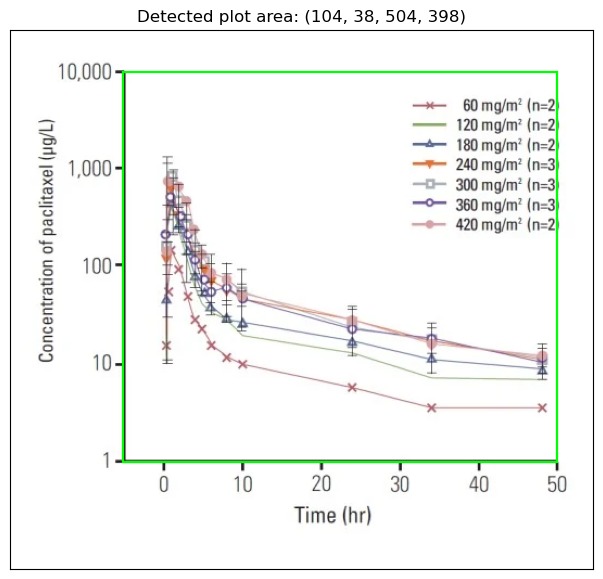

In [4]:
extractor.detect_plot_area()
extractor.visualize_plot_area()
plt.show()

## 3. Tell the algorithm how many trajectories to find

Look at the figure (or its legend) and enter the number of curves. Running this cell will pop up a prompt.

In [5]:
import os
_default_n = os.environ.get("PK_AUTO_N_TRAJECTORIES")
if _default_n is not None:
    N_TRAJECTORIES = int(_default_n)
    print(f"Using PK_AUTO_N_TRAJECTORIES={N_TRAJECTORIES} from env.")
else:
    N_TRAJECTORIES = int(input("How many trajectories are in this figure? ").strip())
print(f"Will look for {N_TRAJECTORIES} trajectories.")

Will look for 7 trajectories.


## 4. Detect markers

Pipeline: saturated mask -> blob candidates (with conservative overlap split when a blob is much bigger than typical) -> line-connectivity graph -> connected components -> color merge to N.

`exclude_regions` masks the legend in image pixel coords (the paclitaxel legend lives at roughly `(345, 75, 485, 235)`).

Tuning knobs (most useful first):

- A trajectory is missing entirely -> lower `min_saturation`.
- Two trajectories merged into one cluster -> step 4a will show a long edge bridging them; raise `line_color_threshold` or shrink `line_max_distance`.
- Hollow markers vanish -> raise `close_radius`.
- A single blob clearly contains two markers but isn't being split -> lower `overlap_size_factor` or `overlap_peak_threshold`.
- The graph fragments into too many groups (and color-merging mixes unrelated colors) -> loosen `line_near_threshold` or `line_color_threshold`.

In [6]:
extractor.detect_markers(
    n_trajectories=N_TRAJECTORIES,
    min_saturation=20,
    exclude_regions=[(345, 75, 485, 235)],
    close_radius=1,
    open_radius=1,
    min_blob_area=8,
    max_blob_area=1500,
    overlap_size_factor=3.0,
    overlap_peak_min_dist=6,
    overlap_peak_threshold=2.5,
    line_max_distance=70,
    line_near_threshold=0.55,
    line_color_threshold=0.30,
)
for name, pts in extractor.trajectories.items():
    print(f"  {name:36s} -> {len(pts):3d} points")

  cluster_0_rgb(177,149,156)           ->  44 points
  cluster_1_rgb(173,155,145)           ->   1 points
  cluster_2_rgb(124,128,156)           ->   1 points
  cluster_3_rgb(160,136,134)           ->   1 points
  cluster_4_rgb(192,160,168)           ->   1 points
  cluster_5_rgb(110,115,137)           ->   1 points
  cluster_6_rgb(188,146,153)           ->   4 points


### 4a. Line-connectivity graph

Each red dot is a candidate marker (yellow = produced by overlap-splitting a single oversized blob into multiple peaks). Lime edges are pairs of markers the algorithm decided are linked by a thin saturated line of compatible color.

What to look for:

- An edge that visibly cuts across two different trajectories means the line check was too lenient -> tighten `line_color_threshold` or shrink `line_max_distance`.
- A trajectory with no edges between its markers means line check was too strict -> loosen those thresholds, or increase `line_max_distance`.
- Yellow dots in dense regions are split markers -- if the same blob has too many yellow dots, raise `overlap_peak_threshold`.

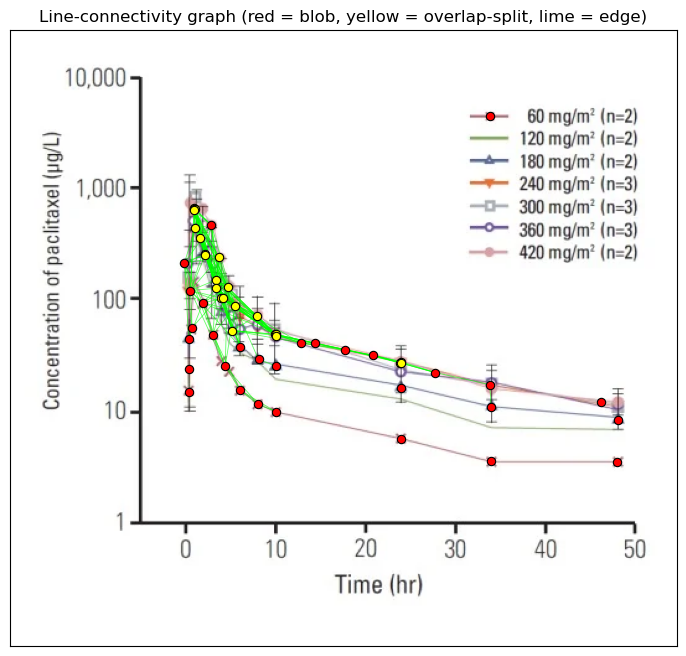

In [7]:
extractor.visualize_graph()
plt.show()

### 4b. What pixels passed the saturation gate?

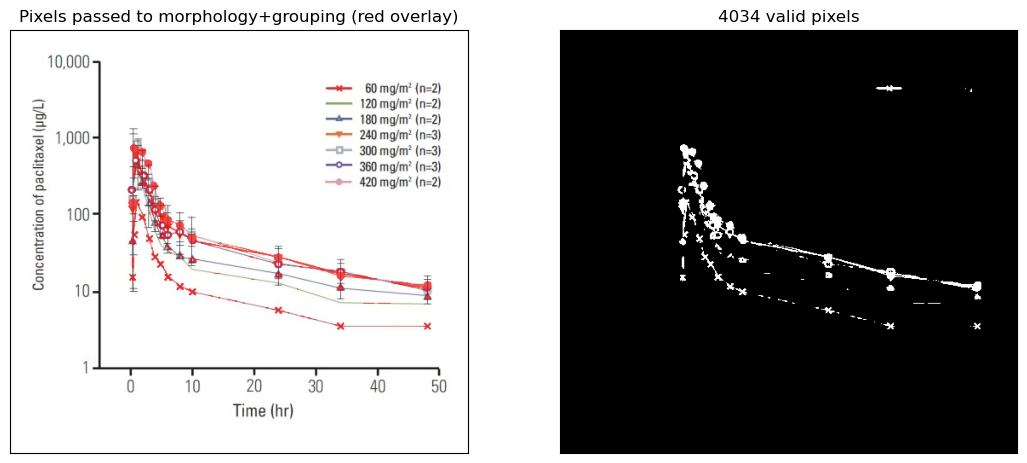

In [8]:
extractor.visualize_valid_mask()
plt.show()

## 5. Verify the detection

Open rings on the original figure mark the centroids that go into the CSV. Each ring is colored with the cluster's mean RGB.

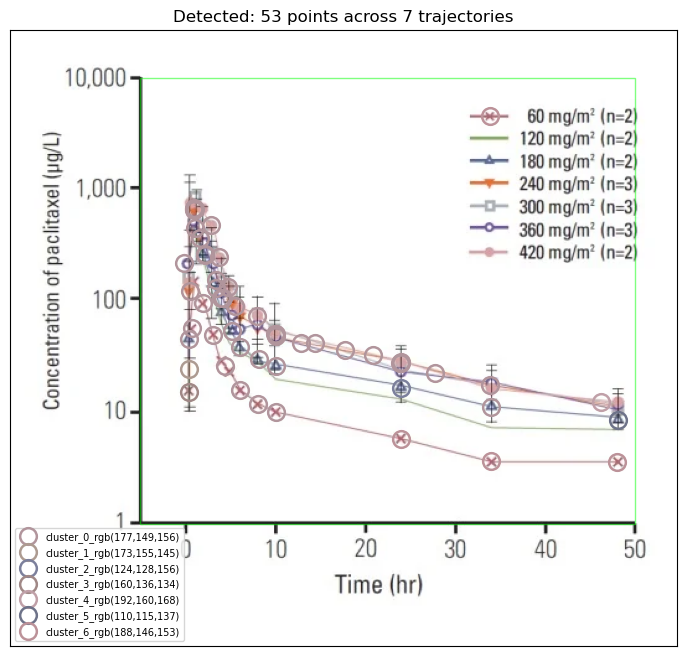

In [9]:
extractor.visualize_detection()
plt.show()

## 6. Save to CSV

In [10]:
df = extractor.save_csv(OUTPUT_CSV)
print(f"Saved {len(df)} points across {df['trajectory'].nunique()} trajectories to {OUTPUT_CSV}")
df.head(20)

Saved 53 points across 7 trajectories to extracted_paclitaxel_auto.csv


,trajectory,x,y
0,"cluster_0_rgb(177,149,156)",4.525862,218.698973
1,"cluster_0_rgb(177,149,156)",4.958333,45.291689
2,"cluster_0_rgb(177,149,156)",5.136792,123.589374
3,"cluster_0_rgb(177,149,156)",5.302632,57.304290
4,"cluster_0_rgb(177,149,156)",5.500000,681.292069
5,"cluster_0_rgb(177,149,156)",5.500000,664.082785
6,"cluster_0_rgb(177,149,156)",5.500000,647.308204
7,"cluster_0_rgb(177,149,156)",5.625000,664.082785
8,"cluster_0_rgb(177,149,156)",5.625000,452.434335
9,"cluster_0_rgb(177,149,156)",6.125000,368.694506


## 7. Round-trip check: re-plot from CSV

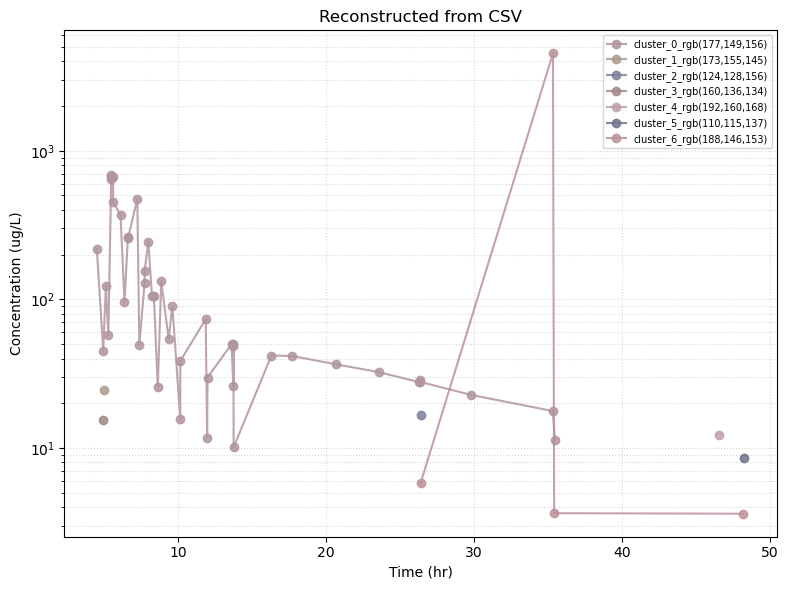

In [11]:
loaded = pd.read_csv(OUTPUT_CSV)
fig, ax = plt.subplots(figsize=(8, 6))
for name, group in loaded.groupby("trajectory", sort=False):
    color = PKFigureAutoExtractor._color_from_name(name)
    ax.plot(group["x"], group["y"], "o-", color=color, label=name, alpha=0.85)
if X_LOG:
    ax.set_xscale("log")
if Y_LOG:
    ax.set_yscale("log")
ax.set_xlabel("Time (hr)")
ax.set_ylabel("Concentration (ug/L)")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend(fontsize=7, loc="best")
ax.set_title("Reconstructed from CSV")
fig.tight_layout()
plt.show()

## Tuning cheatsheet

| Symptom | Likely fix |
|---|---|
| Plot rectangle wrong | `extractor.set_plot_area(L, T, R, B)` |
| Legend icons appear as extra points | extend `exclude_regions` |
| Line graph (4a) bridges across two visibly different trajectories | tighten `line_color_threshold`, lower `line_max_distance`, or lower `line_color_dist` |
| One trajectory has zero edges in 4a | loosen `line_near_threshold` (lines too patchy) and/or raise `line_max_distance` |
| Final result has `< N` trajectories | the lines bridged across trajectories somewhere; tighten line thresholds, or accept and use the click notebook |
| Final result has `> N` trajectories before merge | merging brings dissimilar colors together; raise `N` or loosen line thresholds so groups merge themselves |
| Two markers known to overlap aren't split | lower `overlap_size_factor` (e.g. to 2.0) or `overlap_peak_threshold` (e.g. to 1.8) |
| Tons of yellow split-points appear in dense lump | raise `overlap_peak_threshold` (peaks must be on real markers, not on line bumps) |
| Hollow markers disappear | raise `close_radius` |
| All-grayscale plot (e.g. cisplatin) | the saturation gate eats every pixel -- this notebook can't help; use the click notebook |

## When to fall back to the click notebook

If steps 4a/5 show the algorithm visibly mis-grouping markers and the tuning knobs aren't fixing it, switch to `pk_figure_to_csv.ipynb`. Click extraction is reliable for any figure -- the auto path is best-effort.
